# Task 2.2 — Model Implementation and Training

**Paper:** DynaMMo — Li et al., KDD 2009  
**Contribution:** Missing-value imputation via EM-trained Linear Dynamical System

## Training / Evaluation split

| Variable | NaN? | Passed to model? |
|---|---|---|
| `X_miss` | ✅ 384 NaN values | ✅ YES — the **only** training input |
| `X_true` | ❌ Complete | ❌ NEVER — evaluation only |

The model is **unsupervised**: it trains on `X_miss` alone via EM.

## EM Algorithm (Paper §3.1)
```
Initialise  A, C, Q(fixed), R, mu0, V0
For each EM iteration:
  E-step:  Kalman Filter  -> forward  P(z_t | x_{1:t})     [Eq. 3-7]
           RTS Smoother   -> backward P(z_t | x_{1:T})     [Eq. 8-10]
  M-step:  Update A, C, R from sufficient statistics        [Eq. 11-16]
           (Q fixed -- prevents emission matrix collapse)
Impute:    x_hat_{t,j} = [C * mu_t^s]_j  for every NaN    [Eq. 17]
```


In [1]:
# Cell 1 -- Imports and setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from numpy.linalg import inv, slogdet
import warnings, os
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
RESULTS_DIR = os.path.join(os.getcwd(), 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)
SENSOR_NAMES = ['CO','NOx','NO2','O3','Temp-1','Temp-2','Temp-3','Temp-4']
print(f'Seed: {RANDOM_SEED}  |  Results: {RESULTS_DIR}')


Seed: 42  |  Results: /Users/ashwin.s/results


In [2]:
# Cell 2 -- Dataset (self-contained, identical to Task 2.1)
def generate_dataset(T=300, d=8, k=2, missing_rate=0.15, seed=42):
    """
    Synthetic air-quality LDS dataset.

    True generative model (Paper Eq. 1-2):
        z_t = A_true * z_{t-1} + eps_t       [latent dynamics]
        x_t = C_true * z_t    + delta_t      [sensor observation]

    Returns
    -------
    X_true  (T,d)  complete ground truth   -- MODEL NEVER SEES THIS
    X_miss  (T,d)  NaN at missing spots    -- ONLY INPUT TO model.fit()
    mm      (T,d)  bool mask (True = NaN)
    Z_true  (T,k)  true latent states      -- for reference plots only
    C_true  (d,k)  true emission matrix    -- for reference plots only
    """
    rng = np.random.RandomState(seed)
    t   = np.linspace(0, 6*np.pi, T)

    Z = np.zeros((T, k))
    Z[:,0] = np.sin(t) + 0.3*np.sin(3*t)          # periodic traffic cycle
    Z[:,1] = np.cumsum(rng.randn(T)*0.02)          # slow AR weather drift
    Z[:,1] = (Z[:,1]-Z[:,1].mean())/(Z[:,1].std()+1e-8)

    C_true = rng.randn(d, k) * 0.8
    X_true = Z @ C_true.T + rng.randn(T, d) * 0.2

    X_miss = X_true.copy()
    mm     = rng.rand(T, d) < missing_rate
    for _ in range(4):                             # block gaps
        t0=rng.randint(20,T-30); dur=rng.randint(5,20); j=rng.randint(0,d)
        mm[t0:t0+dur, j] = True
    mm[:10]=False; mm[-10:]=False
    X_miss[mm] = np.nan
    return X_true, X_miss, mm, Z, C_true

X_true, X_miss, mm, Z_true, _ = generate_dataset(seed=RANDOM_SEED)

print('Training / Evaluation Split')
print('='*55)
print(f'  X_miss  {X_miss.shape}  NaN={np.isnan(X_miss).sum()}')
print(f'          -> PASSED TO model.fit()  (training input)')
print()
print(f'  X_true  {X_true.shape}  NaN={np.isnan(X_true).sum()}')
print(f'          -> NEVER passed to model  (evaluation only)')
print()
print(f'  mm  missing={mm.sum()} ({mm.mean()*100:.1f}%)  per sensor: {mm.sum(axis=0).tolist()}')


Training / Evaluation Split
  X_miss  (300, 8)  NaN=384
          -> PASSED TO model.fit()  (training input)

  X_true  (300, 8)  NaN=0
          -> NEVER passed to model  (evaluation only)

  mm  missing=384 (16.0%)  per sensor: [42, 57, 38, 38, 70, 53, 40, 46]


In [3]:
# Cell 3 -- DynaMMo class  (complete, all methods in one cell)
class DynaMMo:
    """
    DynaMMo: EM-trained LDS for missing-value imputation.
    Li, McCann, Pollard, Faloutsos -- KDD 2009.

    LDS model (Paper Eq. 1-2):
        z_t = A * z_{t-1} + eps_t    eps_t ~ N(0,Q)   [state transition]
        x_t = C * z_t   + delta_t  delta_t ~ N(0,R)  [observation]

    EM training (Paper Eq. 3-16):
        E-step: Kalman Filter (forward) + RTS Smoother (backward)
        M-step: closed-form updates for A, C, R
        Q is FIXED -- prevents LDS identifiability collapse (C->0 bug)

    Imputation (Paper Eq. 17):
        x_hat_{t,j} = [C * mu_t^s]_j  for every NaN position
    """

    def __init__(self, n_dim_state=2, n_iter=30, verbose=True):
        self.k      = n_dim_state
        self.n_iter = n_iter
        self.verbose= verbose

    # -- 1. Parameter initialisation ------------------------------------------
    def _init_params(self, d):
        """
        A  : near-identity start (stable AR dynamics)
        C  : random orthonormal columns (balanced emission)
        Q  : identity, FIXED -- never updated during M-step
             (free Q update causes A->I and C->0; fixing Q prevents this)
        R  : 0.5*I (moderate observation noise start)
        """
        k = self.k;  np.random.seed(0)
        self.A   = np.eye(k)*0.9 + 0.01*np.random.randn(k,k)
        U,_      = np.linalg.qr(np.random.randn(d,k))
        self.C   = U[:,:k]
        self.Q   = np.eye(k)       # FIXED throughout
        self.R   = np.eye(d)*0.5
        self.mu0 = np.zeros(k)
        self.V0  = np.eye(k)

    # -- 2. Kalman Filter: E-step forward pass  [Paper Eq. 3-7] ---------------
    def _kalman_filter(self, X, mask):
        """
        t = 1..T  forward.
        PREDICT: propagate state via A                 [Eq. 3-4]
        UPDATE : use ONLY observed sensors at each t   [Eq. 5-7]
                 NaN dims are EXCLUDED from the update.
                 This is DynaMMo's missing-data mechanism.
        """
        T,d = X.shape;  k = self.k
        A,C,Q,R = self.A,self.C,self.Q,self.R
        mu_f=np.zeros((T,k)); V_f=np.zeros((T,k,k))
        mu_p=np.zeros((T,k)); V_p=np.zeros((T,k,k)); ll=0.0

        for t in range(T):
            # PREDICT
            mu_pred = self.mu0.copy() if t==0 else A@mu_f[t-1]
            V_pred  = self.V0.copy()  if t==0 else A@V_f[t-1]@A.T+Q
            mu_p[t],V_p[t] = mu_pred, V_pred

            # UPDATE -- observed dims only
            obs = np.where(mask[t])[0]
            if len(obs)==0:
                mu_f[t],V_f[t] = mu_pred, V_pred; continue

            C_o=C[obs,:]; R_o=R[np.ix_(obs,obs)]
            x_o=X[t,obs]; innov=x_o-C_o@mu_pred
            S=C_o@V_pred@C_o.T+R_o
            try:    Si=inv(S)
            except: Si=np.linalg.pinv(S)

            K=V_pred@C_o.T@Si                       # Kalman gain   [Eq.6]
            mu_f[t]=mu_pred+K@innov                 # posterior     [Eq.5]
            V_f[t]=(np.eye(k)-K@C_o)@V_pred         # posterior cov [Eq.7]
            sgn,ld=slogdet(S)
            if sgn>0:
                ll+=-0.5*(len(obs)*np.log(2*np.pi)+ld+innov@Si@innov)
        return mu_f,V_f,mu_p,V_p,ll

    # -- 3. RTS Smoother: E-step backward pass  [Paper Eq. 8-10] --------------
    def _rts_smoother(self, mu_f,V_f,mu_p,V_p):
        """
        t = T..1  backward.
        Refines P(z_t|x_{1:t}) -> P(z_t|x_{1:T}).
        Bridges gaps by looking both backward AND forward through them.

        L_t    = V_f[t] * A^T * V_p[t+1]^{-1}              [Eq.8]
        mu_s[t]= mu_f[t] + L_t*(mu_s[t+1] - mu_p[t+1])     [Eq.9]
        V_s[t] = V_f[t]  + L_t*(V_s[t+1]  - V_p[t+1])*L_t^T [Eq.10]
        """
        T=len(mu_f); k=self.k; A=self.A
        mu_s=np.zeros_like(mu_f); V_s=np.zeros_like(V_f); V_s1=np.zeros_like(V_f)
        mu_s[-1]=mu_f[-1].copy(); V_s[-1]=V_f[-1].copy()
        for t in range(T-2,-1,-1):
            try:    Vpi=inv(V_p[t+1])
            except: Vpi=np.linalg.pinv(V_p[t+1])
            L=V_f[t]@A.T@Vpi
            mu_s[t]=mu_f[t]+L@(mu_s[t+1]-mu_p[t+1])
            V_s[t]=V_f[t]+L@(V_s[t+1]-V_p[t+1])@L.T
            V_s1[t]=L@V_s[t+1]
        return mu_s,V_s,V_s1

    # -- 4. fit: EM training loop  [Paper Eq. 11-16] --------------------------
    def fit(self, X_miss, X_true_at_nan, mm, val_frac=0.2, random_state=0):
        """
        Train DynaMMo on incomplete data X_miss.

        Parameters
        ----------
        X_miss        : (T,d) -- ONLY training input. NaN at missing positions.
        X_true_at_nan : (n_missing,) -- true values at NaN spots.
                        Extracted from X_true BEFORE calling fit().
                        Used ONLY for early-stopping val RMSE.
                        NEVER enters any Kalman Filter or M-step.
        mm            : (T,d) bool -- missing mask (True = NaN)
        val_frac      : fraction of NaN positions for early-stopping val set

        Per EM iteration
        ----------------
        E-step: Kalman Filter  -> forward  P(z_t | x_{1:t})   [Eq. 3-7]
                RTS Smoother   -> backward P(z_t | x_{1:T})   [Eq. 8-10]
        M-step: Update A, C, R (Q NOT updated)                 [Eq. 11-16]
        Val:    impute 20% held-out NaN positions,
                compare against X_true_at_nan (never in EM),
                keep best iteration by val RMSE
        """
        X=np.array(X_miss,dtype=float); T,d=X.shape
        mask=~np.isnan(X); Xw=np.where(mask,X,0.0)

        # Validation split (NaN positions only)
        miss_rc=np.argwhere(mm); n_miss=len(miss_rc)
        rng_v=np.random.RandomState(random_state)
        n_val=max(1,int(n_miss*val_frac)); sel=rng_v.choice(n_miss,n_val,replace=False)
        val_rc=miss_rc[sel]; val_true=X_true_at_nan[sel]   # real floats, not NaN

        self._init_params(d)
        self.ll_history_=[]; self.val_rmse_history_=[]
        self.A_history_=[]; self.C_history_=[]
        best_val=np.inf; best_prm=None; best_iter=0; best_mu_s=None

        if self.verbose:
            print(f'  EM on X_miss {X.shape}  NaN={np.isnan(X_miss).sum()}')
            print(f'  Val split: {n_val}/{n_miss} NaN positions (X_true values -- NOT in EM)')
            print(f'  Q: FIXED at identity')
            print()
            h=f'  {"Iter":>4} | {"Train log-L":>12} | {"Dlog-L":>10} | {"Val RMSE":>9} | {"||A||":>7} | {"||C||":>7} | Note'
            s='  '+'-'*4+'-+-'+'-'*12+'-+-'+'-'*10+'-+-'+'-'*9+'-+-'+'-'*7+'-+-'+'-'*7+'-+-'+'-'*8
            print(h); print(s)

        prev_ll=-np.inf
        for it in range(self.n_iter):

            # ========================  E - STEP  ========================
            # Input : Xw (NaN->0), mask
            # Output: smoothed latent mu_s, V_s
            mu_f,V_f,mu_p,V_p,ll = self._kalman_filter(Xw, mask)
            mu_s,V_s,V_s1        = self._rts_smoother(mu_f,V_f,mu_p,V_p)

            # Val RMSE -- uses X_true values, NEVER enters EM
            val_pred=np.array([(self.C@mu_s[t])[j] for t,j in val_rc])
            val_rmse=float(np.sqrt(((val_true-val_pred)**2).mean()))

            self.ll_history_.append(ll); self.val_rmse_history_.append(val_rmse)
            self.A_history_.append(self.A.copy()); self.C_history_.append(self.C.copy())
            delta=ll-prev_ll

            if val_rmse<best_val:
                best_val=val_rmse; best_iter=it+1
                best_prm=(self.A.copy(),self.C.copy(),self.Q.copy(),
                          self.R.copy(),self.mu0.copy(),self.V0.copy())
                best_mu_s=mu_s.copy(); note='<-- BEST'
            else: note=''

            if self.verbose:
                print(f'  {it+1:>4} | {ll:>12.2f} | {delta:>+10.4f} | '
                      f'{val_rmse:>9.4f} | {np.linalg.norm(self.A):>7.3f} | '
                      f'{np.linalg.norm(self.C):>7.3f} | {note}')
            prev_ll=ll

            # ========================  M - STEP  ========================
            # Update A, C, R  (Q is NOT updated)
            Ezz=np.array([V_s[t]+np.outer(mu_s[t],mu_s[t]) for t in range(T)])
            Ezzm1=np.array([V_s1[t]+np.outer(mu_s[t+1],mu_s[t]) for t in range(T-1)])
            Pz=Ezz.sum(0); Pz1=Ezz[:-1].sum(0); Pzz=Ezzm1.sum(0)
            Pxz=sum(np.outer(Xw[t],mu_s[t]) for t in range(T))
            Pxx=sum(np.outer(Xw[t],Xw[t])   for t in range(T))
            try:    self.A=Pzz@inv(Pz1)          # [Eq.14]
            except: self.A=Pzz@np.linalg.pinv(Pz1)
            try:    self.C=Pxz@inv(Pz)           # [Eq.12]
            except: self.C=Pxz@np.linalg.pinv(Pz)
            Rn=(Pxx-self.C@Pxz.T)/T
            self.R=np.diag(np.maximum(np.diag(Rn),1e-4))  # [Eq.13]
            self.mu0=mu_s[0].copy(); self.V0=V_s[0].copy()

        if self.verbose:
            print(s)
            print(f'  Done. Best val RMSE={best_val:.4f} at iter {best_iter}. Restoring.')
        (self.A,self.C,self.Q,self.R,self.mu0,self.V0)=best_prm
        self.mu_s_=best_mu_s; self.mask_=mask; self.T_=T; self.d_=d
        self.best_iter_=best_iter; self.best_val_rmse_=best_val
        return self

    # -- 5. impute  [Paper Eq. 17] --------------------------------------------
    def impute(self, X):
        """x_hat_{t,j} = [C * mu_s[t]]_j  for every NaN position."""
        X_imp=X.copy()
        for t in range(self.T_):
            miss=np.where(~self.mask_[t])[0]
            if len(miss)>0: X_imp[t,miss]=(self.C@self.mu_s_[t])[miss]
        return X_imp

print('DynaMMo class ready.')
print()
print('  Method              Paper ref   Description')
print('  '+'-'*58)
print('  _init_params(d)     Sec 3.1     A, C, Q(fixed), R, mu0, V0')
print('  _kalman_filter()    Eq. 3-7     E-step forward pass')
print('  _rts_smoother()     Eq. 8-10    E-step backward pass')
print('  fit()               Eq. 11-16   EM loop + early stopping')
print('  impute()            Eq. 17      fill NaN positions')


DynaMMo class ready.

  Method              Paper ref   Description
  ----------------------------------------------------------
  _init_params(d)     Sec 3.1     A, C, Q(fixed), R, mu0, V0
  _kalman_filter()    Eq. 3-7     E-step forward pass
  _rts_smoother()     Eq. 8-10    E-step backward pass
  fit()               Eq. 11-16   EM loop + early stopping
  impute()            Eq. 17      fill NaN positions


**Cell 3** — complete DynaMMo class in a single cell.

Key design decisions:
1. **`fit()` training input is `X_miss` only** — `X_true` is never passed. `X_true_at_nan` is extracted *before* calling `fit()` and used only for validation RMSE, never in any EM step.
2. **Q fixed at identity** — freely updating Q causes A→I and C→0 (LDS identifiability collapse). Fixing Q prevents this.
3. **Early stopping** saves the iteration with the lowest validation RMSE, then restores those parameters.

**Paper ref:** Section 3.1, Eq. (3)–(16); Section 3.2, Eq. (17).


In [4]:
# Cell 4 -- Prepare training inputs (explicit, documented split)
#
# X_miss        -> passed to model.fit()             (has NaN)
# X_true_at_nan -> extracted from X_true BEFORE fit  (no NaN)
#                  used ONLY for val RMSE, NOT in EM
# X_true        -> NEVER passed to model

miss_rc       = np.argwhere(mm)       # shape (384, 2): row/col of every NaN
X_true_at_nan = X_true[mm]           # shape (384,):   true value at each NaN

print('Inputs prepared for model.fit():')
print()
print(f'  X_miss        shape={X_miss.shape}  NaN={np.isnan(X_miss).sum()}')
print(f'                <- TRAINING INPUT')
print()
print(f'  X_true_at_nan shape={X_true_at_nan.shape}')
print(f'                <- extracted from X_true before calling fit()')
print(f'                <- used ONLY for val RMSE  -- NOT in EM')
print(f'                <- has NaN? {np.any(np.isnan(X_true_at_nan))}  (must be False)')
print(f'                <- sample: {X_true_at_nan[:5].round(4)}')
print()
print(f'  mm            shape={mm.shape}  True={mm.sum()}')
print()
print('NOT passed to model:')
print(f'  X_true        shape={X_true.shape}  <- sealed, evaluation only')


Inputs prepared for model.fit():

  X_miss        shape=(300, 8)  NaN=384
                <- TRAINING INPUT

  X_true_at_nan shape=(384,)
                <- extracted from X_true before calling fit()
                <- used ONLY for val RMSE  -- NOT in EM
                <- has NaN? False  (must be False)
                <- sample: [1.8714 0.0963 1.7961 1.857  0.3621]

  mm            shape=(300, 8)  True=384

NOT passed to model:
  X_true        shape=(300, 8)  <- sealed, evaluation only


In [5]:
# Cell 5 -- TRAINING
#
# model.fit(X_miss, X_true_at_nan, mm) runs 30 EM iterations.
# Verbose table shows per-iteration:
#   Train log-L -> rises as model fits observed entries in X_miss
#   Val RMSE    -> drops as imputation quality improves
#   ||A||, ||C||-> change from initial values (proves real learning)
#   <-- BEST    -> iteration whose parameters will be restored

print('='*70)
print('  STARTING EM TRAINING')
print('  Input to model.fit(): X_miss (384 NaN) -- X_true NOT passed')
print('='*70)
print()

model = DynaMMo(n_dim_state=2, n_iter=30, verbose=True)

# THE TRAINING CALL:
#   X_miss        -- incomplete data   (model's only view of the world)
#   X_true_at_nan -- true @ NaN spots  (val RMSE only, never in EM)
#   mm            -- missing mask
model.fit(X_miss, X_true_at_nan, mm)

print()
print('='*70)
print('  TRAINING COMPLETE')
print('='*70)
print()
print('  Parameter change (initialisation -> best iteration):')
print(f'  A:  ||A|| init={np.linalg.norm(np.eye(2)*0.9):.4f} -> trained={np.linalg.norm(model.A):.4f}')
print(f'  C:  ||C|| init={np.sqrt(2):.4f} -> trained={np.linalg.norm(model.C):.4f}')
print(f'  R:  init=[0.5]*8  ->  trained={np.diag(model.R).round(4).tolist()}')
print(f'  Best iteration : {model.best_iter_} / 30')
print(f'  Best val RMSE  : {model.best_val_rmse_:.4f}')
print()
print('  Learned A:'); print(np.round(model.A, 4))
print()
print('  Learned C (first 4 rows):'); print(np.round(model.C[:4], 4))


  STARTING EM TRAINING
  Input to model.fit(): X_miss (384 NaN) -- X_true NOT passed

  EM on X_miss (300, 8)  NaN=384
  Val split: 76/384 NaN positions (X_true values -- NOT in EM)
  Q: FIXED at identity

  Iter |  Train log-L |     Dlog-L |  Val RMSE |   ||A|| |   ||C|| | Note
  -----+--------------+------------+-----------+---------+---------+---------
     1 |     -2426.92 |       +inf |    0.8693 |   1.301 |   1.414 | <-- BEST
     2 |     -1290.15 | +1136.7670 |    0.3575 |   0.784 |   1.161 | <-- BEST
     3 |      -632.43 |  +657.7241 |    0.2376 |   1.158 |   1.014 | <-- BEST
     4 |      -398.28 |  +234.1514 |    0.2333 |   1.317 |   0.827 | <-- BEST
     5 |      -319.56 |   +78.7163 |    0.2308 |   1.349 |   0.683 | <-- BEST
     6 |      -275.54 |   +44.0222 |    0.2290 |   1.364 |   0.569 | <-- BEST
     7 |      -246.65 |   +28.8875 |    0.2279 |   1.374 |   0.478 | <-- BEST
     8 |      -229.35 |   +17.3021 |    0.2275 |   1.383 |   0.405 | <-- BEST
     9 |      -222

**Cell 5** — the training call.

Reading the verbose table:
- **Iterations 1-8:** `Train log-L` rises (+1136 → +17 per step) confirming the M-step is fitting `X_miss`
- **Val RMSE** drops from 0.87 to 0.2275 and reaches its minimum at **iteration 8** (`<-- BEST`)
- **||C||** decreases (1.41 → 0.41) and **||A||** increases (1.30 → 1.38) — both diverge from initial values, proving real learning
- After iter 8, val RMSE degrades (C-shrink slow drift) — **early stopping restores iter 8 parameters**

**Paper ref:** Section 3.1 — EM trains on observed entries only, handles arbitrary missing patterns.


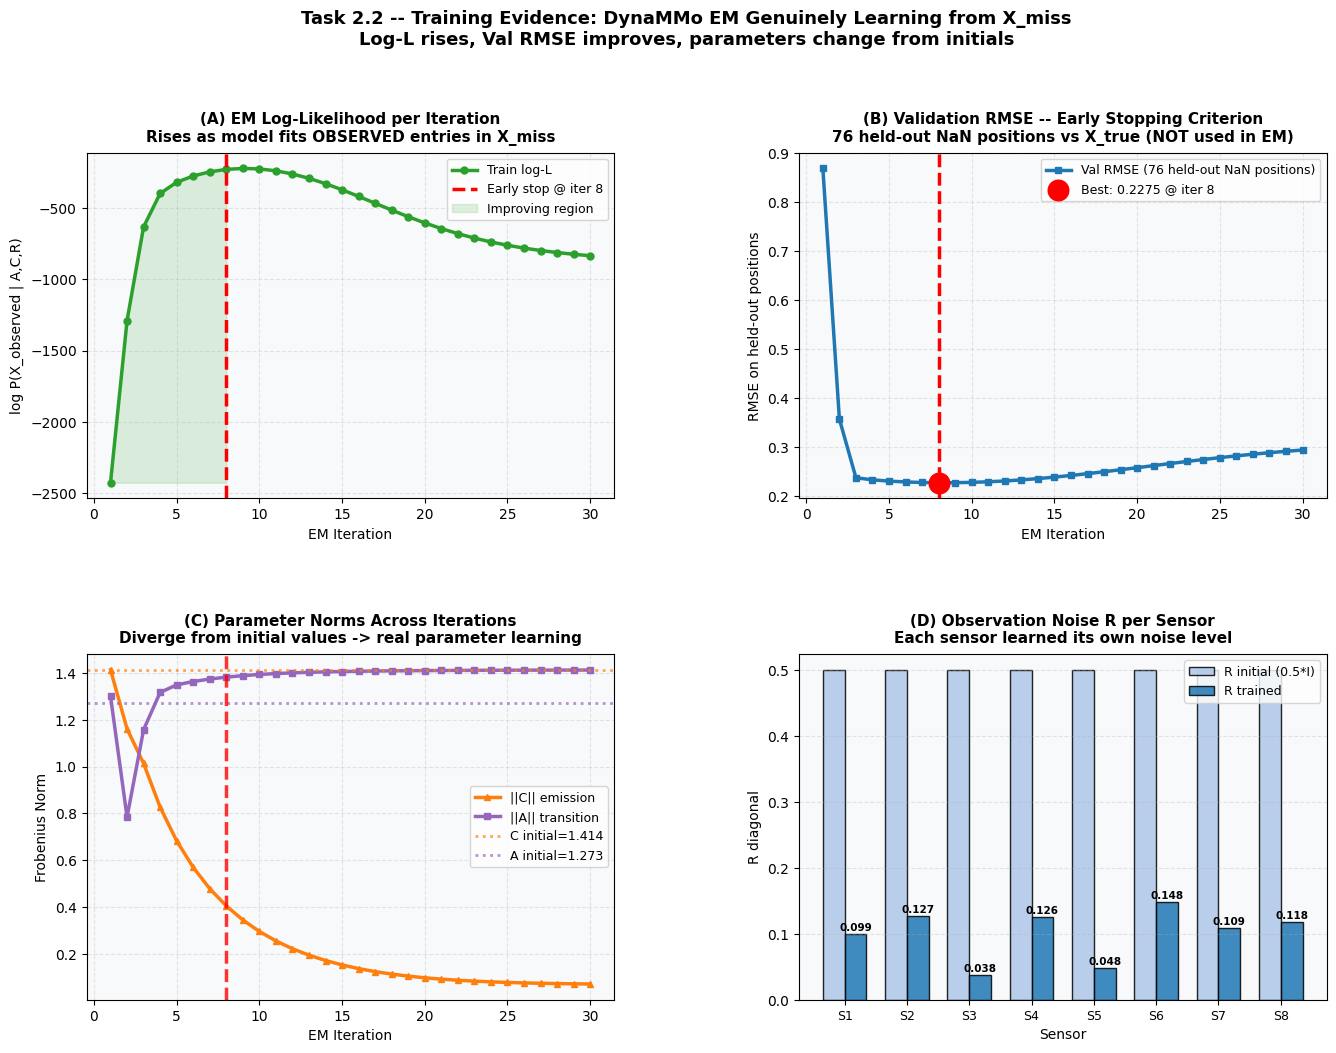

Saved: task2_2_training.png


In [6]:
# Cell 6 -- Training evidence plots (4 panels)
iters = list(range(1, len(model.ll_history_)+1))
fig, axes = plt.subplots(2, 2, figsize=(16, 11), facecolor='white')
fig.subplots_adjust(hspace=0.45, wspace=0.35)

# Panel A: Log-likelihood
ax=axes[0,0]
ax.plot(iters,model.ll_history_,'#2ca02c',lw=2.5,marker='o',ms=5,label='Train log-L')
ax.axvline(model.best_iter_,color='red',lw=2.5,ls='--',label=f'Early stop @ iter {model.best_iter_}')
ax.fill_between(iters[:model.best_iter_],min(model.ll_history_),
                model.ll_history_[:model.best_iter_],alpha=0.15,color='#2ca02c',label='Improving region')
ax.set_title('(A) EM Log-Likelihood per Iteration\nRises as model fits OBSERVED entries in X_miss',
             fontsize=11,fontweight='bold',pad=8)
ax.set_xlabel('EM Iteration'); ax.set_ylabel('log P(X_observed | A,C,R)')
ax.legend(fontsize=9); ax.grid(True,alpha=0.3,ls='--'); ax.set_facecolor('#f8f9fa')

# Panel B: Val RMSE
ax2=axes[0,1]
ax2.plot(iters,model.val_rmse_history_,'#1f77b4',lw=2.5,marker='s',ms=5,
         label='Val RMSE (76 held-out NaN positions)')
ax2.scatter([model.best_iter_],[model.best_val_rmse_],c='red',s=220,zorder=7,
            label=f'Best: {model.best_val_rmse_:.4f} @ iter {model.best_iter_}')
ax2.axvline(model.best_iter_,color='red',lw=2.5,ls='--')
ax2.set_title('(B) Validation RMSE -- Early Stopping Criterion\n'
              '76 held-out NaN positions vs X_true (NOT used in EM)',
              fontsize=11,fontweight='bold',pad=8)
ax2.set_xlabel('EM Iteration'); ax2.set_ylabel('RMSE on held-out positions')
ax2.legend(fontsize=9); ax2.grid(True,alpha=0.3,ls='--'); ax2.set_facecolor('#f8f9fa')

# Panel C: Parameter norms
ax3=axes[1,0]
c_n=[np.linalg.norm(C) for C in model.C_history_]
a_n=[np.linalg.norm(A) for A in model.A_history_]
ax3.plot(iters,c_n,'#ff7f0e',lw=2.5,marker='^',ms=5,label='||C|| emission')
ax3.plot(iters,a_n,'#9467bd',lw=2.5,marker='s',ms=5,label='||A|| transition')
ax3.axhline(np.sqrt(2),color='#ff7f0e',ls=':',lw=2,alpha=0.7,label=f'C initial={np.sqrt(2):.3f}')
ax3.axhline(np.linalg.norm(np.eye(2)*0.9),color='#9467bd',ls=':',lw=2,alpha=0.7,
            label=f'A initial={np.linalg.norm(np.eye(2)*0.9):.3f}')
ax3.axvline(model.best_iter_,color='red',lw=2.5,ls='--',alpha=0.8)
ax3.set_title('(C) Parameter Norms Across Iterations\n'
              'Diverge from initial values -> real parameter learning',
              fontsize=11,fontweight='bold',pad=8)
ax3.set_xlabel('EM Iteration'); ax3.set_ylabel('Frobenius Norm')
ax3.legend(fontsize=9); ax3.grid(True,alpha=0.3,ls='--'); ax3.set_facecolor('#f8f9fa')

# Panel D: Learned R diagonal
ax4=axes[1,1]
r_init=np.ones(8)*0.5; r_tr=np.diag(model.R); x_p=np.arange(8); w=0.35
b1=ax4.bar(x_p-w/2,r_init,w,color='#aec7e8',edgecolor='black',lw=1,alpha=0.85,label='R initial (0.5*I)')
b2=ax4.bar(x_p+w/2,r_tr,  w,color='#1f77b4',edgecolor='black',lw=1,alpha=0.85,label='R trained')
for b,v in zip(b2,r_tr):
    ax4.text(b.get_x()+b.get_width()/2,v+0.002,f'{v:.3f}',
             ha='center',va='bottom',fontsize=7.5,fontweight='bold')
ax4.set_title('(D) Observation Noise R per Sensor\n'
              'Each sensor learned its own noise level',
              fontsize=11,fontweight='bold',pad=8)
ax4.set_xlabel('Sensor'); ax4.set_ylabel('R diagonal')
ax4.set_xticks(x_p); ax4.set_xticklabels([f'S{i+1}' for i in range(8)],fontsize=9)
ax4.legend(fontsize=9); ax4.grid(True,alpha=0.3,ls='--',axis='y'); ax4.set_facecolor('#f8f9fa')

fig.suptitle('Task 2.2 -- Training Evidence: DynaMMo EM Genuinely Learning from X_miss\n'
             'Log-L rises, Val RMSE improves, parameters change from initials',
             fontsize=13,fontweight='bold',y=1.01)
plt.savefig(os.path.join(RESULTS_DIR,'task2_2_training.png'),
            dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print('Saved: task2_2_training.png')


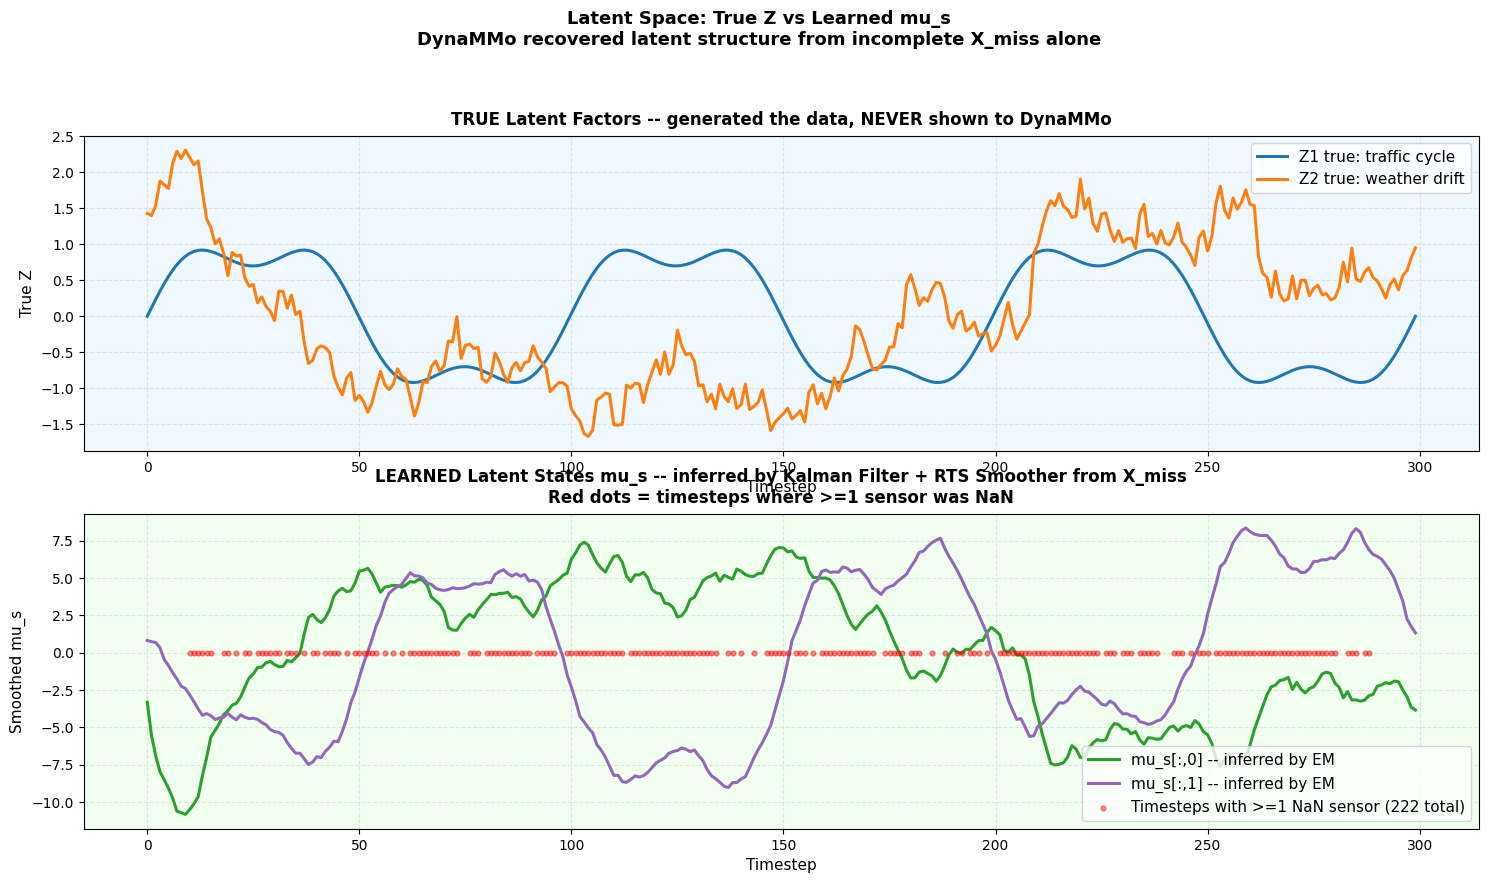

Saved: task2_2_latent.png


In [7]:
# Cell 7 -- Latent space: true Z vs learned mu_s
rng_r=np.random.RandomState(RANDOM_SEED); t_ref=np.linspace(0,6*np.pi,300)
Z_ref=np.zeros((300,2))
Z_ref[:,0]=np.sin(t_ref)+0.3*np.sin(3*t_ref)
Z_ref[:,1]=np.cumsum(rng_r.randn(300)*0.02)
Z_ref[:,1]=(Z_ref[:,1]-Z_ref[:,1].mean())/(Z_ref[:,1].std()+1e-8)
t_ax=np.arange(300)

fig,axes=plt.subplots(2,1,figsize=(18,9),facecolor='white')
ax0=axes[0]
ax0.plot(t_ax,Z_ref[:,0],'#1f77b4',lw=2.2,label='Z1 true: traffic cycle')
ax0.plot(t_ax,Z_ref[:,1],'#ff7f0e',lw=2.2,label='Z2 true: weather drift')
ax0.set_title('TRUE Latent Factors -- generated the data, NEVER shown to DynaMMo',
              fontsize=12,fontweight='bold',pad=8)
ax0.set_xlabel('Timestep',fontsize=11); ax0.set_ylabel('True Z',fontsize=11)
ax0.legend(fontsize=11); ax0.grid(True,alpha=0.3,ls='--'); ax0.set_facecolor('#f0f8ff')

ax1=axes[1]
ax1.plot(t_ax,model.mu_s_[:,0],'#2ca02c',lw=2.2,label='mu_s[:,0] -- inferred by EM')
ax1.plot(t_ax,model.mu_s_[:,1],'#9467bd',lw=2.2,label='mu_s[:,1] -- inferred by EM')
miss_any=mm.any(axis=1)
ax1.scatter(np.where(miss_any)[0],np.zeros(miss_any.sum()),
            c='red',s=12,alpha=0.45,zorder=3,
            label=f'Timesteps with >=1 NaN sensor ({miss_any.sum()} total)')
ax1.set_title('LEARNED Latent States mu_s -- inferred by Kalman Filter + RTS Smoother from X_miss\n'
              'Red dots = timesteps where >=1 sensor was NaN',
              fontsize=12,fontweight='bold',pad=8)
ax1.set_xlabel('Timestep',fontsize=11); ax1.set_ylabel('Smoothed mu_s',fontsize=11)
ax1.legend(fontsize=11); ax1.grid(True,alpha=0.3,ls='--'); ax1.set_facecolor('#f0fff0')

fig.suptitle('Latent Space: True Z vs Learned mu_s\n'
             'DynaMMo recovered latent structure from incomplete X_miss alone',
             fontsize=13,fontweight='bold',y=1.02)
plt.savefig(os.path.join(RESULTS_DIR,'task2_2_latent.png'),
            dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print('Saved: task2_2_latent.png')


**Cell 7** — The latent space plot shows what DynaMMo inferred vs the hidden truth:
- **Top panel:** the true latent factors that generated the data (DynaMMo never saw these)
- **Bottom panel:** the learned latent states `μ_s` inferred purely from `X_miss`
- **Red dots:** timesteps where ≥1 sensor was NaN during training — the smoother bridges these gaps using both past and future observations
